# Notebook 02 — Environmental signals EDA

Descriptive environmental EDA using the assembled dataset and Notebook 01 audit outputs.


## 0. Imports and setup


In [155]:
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import seaborn as sns  # noqa: F401
    _HAVE_SEABORN = True
except Exception:
    _HAVE_SEABORN = False


In [156]:
# Dependency preflight: parquet support (read/write)
try:
    import pyarrow  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "Missing optional dependency 'pyarrow' required for parquet IO in this notebook. "
        "Install with: pip install pyarrow"
    ) from exc


In [157]:
def find_project_root(start_path: Path) -> Path:
    """Find the project root by walking upward from a start path.

    Markers searched (in priority order):
    - pyproject.toml
    - README.md
    - data/ directory

    The notebook must not assume the execution CWD is already the project root.
    """

    best_candidate = None
    best_score = -1

    for candidate in [start_path, *start_path.parents]:
        has_pyproject = (candidate / 'pyproject.toml').exists()
        has_readme = (candidate / 'README.md').exists()
        has_data_dir = (candidate / 'data').is_dir()

        score = 0
        score += 4 if has_pyproject else 0
        score += 2 if has_readme else 0
        score += 1 if has_data_dir else 0

        if score > best_score:
            best_candidate = candidate
            best_score = score

        if has_data_dir and (has_pyproject or has_readme):
            return candidate

    if best_candidate is not None and (best_candidate / 'data').is_dir():
        return best_candidate

    raise FileNotFoundError(
        "Could not locate PROJECT_ROOT by walking upward from the current working directory. "
        "Expected to find at least a 'data/' directory and ideally 'README.md' or 'pyproject.toml'."
    )


In [158]:
PROJECT_ROOT = find_project_root(Path.cwd().resolve())

ASSEMBLED_PATH = PROJECT_ROOT / 'data' / 'interim' / 'beijing_air_quality' / 'beijing_multisite_assembled.parquet'
AUDIT_SUMMARY_PATH = PROJECT_ROOT / 'data' / 'interim' / 'beijing_air_quality' / 'temporal_audit' / 'temporal_audit_summary.json'
STATION_STATUS_PATH = PROJECT_ROOT / 'data' / 'interim' / 'beijing_air_quality' / 'temporal_audit' / 'station_status_policy.parquet'
STATION_COVERAGE_PATH = PROJECT_ROOT / 'data' / 'interim' / 'beijing_air_quality' / 'temporal_audit' / 'station_coverage_summary.parquet'

FIG_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'eda_environmental_signals'
TAB_DIR = PROJECT_ROOT / 'data' / 'interim' / 'beijing_air_quality' / 'eda_environmental_signals'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

PM25_COL = 'PM2.5'
KEYS = ['station', 'timestamp']

POLLUTANTS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
METEOROLOGY = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd']

MIN_EPISODE_HOURS = 6

# Required curated figure filenames
FIG_PM25_GLOBAL = 'pm25_distribution_global.png'
FIG_PM25_BY_STATION = 'pm25_by_station_boxplot.png'
FIG_STATION_MONTH_HEATMAP = 'station_month_pm25_heatmap.png'
FIG_PM25_DIURNAL = 'pm25_diurnal_profile.png'
FIG_PM25_MONTHLY_TREND = 'pm25_monthly_trend.png'
FIG_CORR_HEATMAP = 'corr_heatmap_pollutants_meteo.png'
FIG_PM25_WSPM_HEXBIN = 'pm25_vs_wspm_hexbin.png'
FIG_PM25_WD_BAR = 'pm25_by_wd_bar.png'
FIG_EPISODE_DUR_HIST = 'episode_duration_hist.png'
FIG_EPISODE_STATION_MONTH = 'episode_station_month_heatmap.png'

# Required support tables
TAB_PM25_SUMMARY_GLOBAL = 'pm25_summary_global.parquet'
TAB_PM25_SUMMARY_BY_STATION = 'pm25_summary_by_station.parquet'
TAB_STATION_MONTH_PM25 = 'station_month_pm25_summary.parquet'
TAB_PM25_TEMPORAL_AGGS = 'pm25_temporal_aggregates.parquet'
TAB_CORR_GLOBAL = 'correlations_global.parquet'
TAB_CORR_BY_SEASON = 'correlations_by_season.parquet'
TAB_WEATHER_BINNED = 'weather_binned_summaries.parquet'
TAB_EPISODE_SUMMARY = 'episode_summary.parquet'
TAB_EPISODE_EVENTS = 'episode_events.parquet'
TAB_IMPLICATIONS = 'eda_modeling_implications.parquet'

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'FIG_DIR: {FIG_DIR}')
print(f'TAB_DIR: {TAB_DIR}')


PROJECT_ROOT: F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portfolio_data_science\air-quality-forecasting-environmental-signals
FIG_DIR: F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portfolio_data_science\air-quality-forecasting-environmental-signals\reports\figures\eda_environmental_signals
TAB_DIR: F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portfolio_data_science\air-quality-forecasting-environmental-signals\data\interim\beijing_air_quality\eda_environmental_signals


## 1. Notebook scope, EDA contract, and inputs

Notebook 02 performs **descriptive environmental EDA**, not modeling.

EDA observations may motivate later modeling choices but do **not** implement or freeze them here.

This notebook does **not** perform: imputation, split design, target construction, horizons, lags/features, baselines, leakage analysis, or modeling.

All modeling implications must reference a specific table or figure produced in this notebook.

Notebook 03 will use these findings to design the forecasting problem contract.

Persisted figures are curated analytical outputs (not every exploratory plot).


## 2. Load assembled dataset and audit artifacts


In [159]:
if not ASSEMBLED_PATH.exists():
    raise FileNotFoundError(f'Missing assembled parquet: {ASSEMBLED_PATH}')
if not AUDIT_SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Missing temporal audit summary: {AUDIT_SUMMARY_PATH}')
if not STATION_STATUS_PATH.exists():
    raise FileNotFoundError(f'Missing station status policy: {STATION_STATUS_PATH}')
if not STATION_COVERAGE_PATH.exists():
    raise FileNotFoundError(f'Missing station coverage summary: {STATION_COVERAGE_PATH}')

df = pd.read_parquet(ASSEMBLED_PATH)

with AUDIT_SUMMARY_PATH.open('r', encoding='utf-8') as f:
    temporal_audit_summary = json.load(f)

station_status_policy = pd.read_parquet(STATION_STATUS_PATH)
station_coverage_summary = pd.read_parquet(STATION_COVERAGE_PATH)

missing_core = [c for c in ['station', 'timestamp', PM25_COL] if c not in df.columns]
if missing_core:
    raise ValueError(f'Missing core columns: {missing_core}')

if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    parsed = pd.to_datetime(df['timestamp'], errors='coerce')
    if int(parsed.isna().sum()) > 0:
        raise ValueError('timestamp could not be parsed cleanly (nulls introduced)')
    df = df.copy()
    df['timestamp'] = parsed

stations_df = set(df['station'].astype(str).unique().tolist())
stations_policy = set(station_status_policy['station'].astype(str).unique().tolist())
if stations_df != stations_policy:
    raise ValueError('Station set mismatch between assembled data and station_status_policy')

status_counts = station_status_policy['status'].value_counts(dropna=False)
status_counts


status
include    12
Name: count, dtype: int64

## 3. Apply audit station statuses


In [160]:
eligible_statuses = {'include', 'caution'}
eligible_stations = set(
    station_status_policy.loc[station_status_policy['status'].isin(eligible_statuses), 'station']
    .astype(str)
    .tolist()
)

if not eligible_stations:
    raise ValueError('No include/caution stations available for EDA')

df_eda = df[df['station'].astype(str).isin(eligible_stations)].copy()
df_eda = df_eda.merge(
    station_status_policy[['station', 'status', 'missing_rate', 'pm25_missing_rate', 'severe_sanity_flag']],
    on='station',
    how='left',
)

if int(df_eda['status'].isna().sum()) > 0:
    raise ValueError('Status merge produced missing station statuses')

df_eda.shape


(420768, 24)

## 4. Dataset overview and missingness recap

Question: *What does the overall PM2.5 distribution look like after applying the audit station filter, and how much data is available?*

Notebook 03 relevance: informs whether the forecasting contract should plan for heavy tails and whether station coverage is sufficient for pooled vs per-station evaluation (decision remains open here).


In [161]:
pm25 = df_eda[PM25_COL].astype(float)

quantiles = {
    'p1': 0.01,
    'p5': 0.05,
    'p25': 0.25,
    'p50': 0.50,
    'p75': 0.75,
    'p90': 0.90,
    'p95': 0.95,
    'p99': 0.99,
}

pm25_summary_global = {
    'count': int(pm25.notna().sum()),
    'mean': float(pm25.mean()),
    'std': float(pm25.std(ddof=1)),
    'max': float(pm25.max()),
}
for name, q in quantiles.items():
    pm25_summary_global[name] = float(pm25.quantile(q))

pm25_summary_global_df = (
    pd.Series(pm25_summary_global, name='value')
    .rename_axis('metric')
    .reset_index()
)

pm25_summary_global_df.to_parquet(TAB_DIR / TAB_PM25_SUMMARY_GLOBAL, index=False)
pm25_summary_global_df


,metric,value
0,count,412029.000000
1,mean,79.793428
2,std,80.822391
3,max,999.000000
4,p1,3.000000
5,p5,6.000000
6,p25,20.000000
7,p50,55.000000
8,p75,111.000000
9,p90,185.000000


## 5. PM2.5 distribution: global and by station

Question: *How does PM2.5 vary across stations in typical level and dispersion?*

Notebook 03 relevance: informs whether station effects are large enough that the contract should track station-stratified performance (without committing to a modeling approach).


In [162]:
def pm25_station_summary(df_in: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for station_name, group in df_in.groupby('station', sort=True):
        s = group[PM25_COL].astype(float)
        row = {
            'station': station_name,
            'count': int(s.notna().sum()),
            'mean': float(s.mean()),
            'std': float(s.std(ddof=1)),
            'max': float(s.max()),
        }
        for name, q in {
            'p1': 0.01,
            'p5': 0.05,
            'p25': 0.25,
            'p50': 0.50,
            'p75': 0.75,
            'p90': 0.90,
            'p95': 0.95,
            'p99': 0.99,
        }.items():
            row[name] = float(s.quantile(q))
        rows.append(row)
    return pd.DataFrame(rows).sort_values('station').reset_index(drop=True)


In [163]:
pm25_summary_by_station = pm25_station_summary(df_eda)
pm25_summary_by_station.to_parquet(TAB_DIR / TAB_PM25_SUMMARY_BY_STATION, index=False)

# Station ranking view (median and p95)
pm25_summary_by_station[['station', 'p50', 'p95', 'mean', 'count']].sort_values('p50', ascending=False).reset_index(drop=True)


,station,p50,p95,mean,count
0,Dongsi,61.0,260.0,86.194297,34314
1,Gucheng,60.0,247.0,83.852089,34418
2,Wanshouxigong,60.0,256.0,85.024136,34368
3,Nongzhanguan,59.0,260.0,84.838483,34436
4,Wanliu,59.0,247.0,83.374716,34682
5,Tiantan,59.0,243.7,82.164911,34387
6,Guanyuan,59.0,243.0,82.933372,34448
7,Aotizhongxin,58.0,248.0,82.773611,34139
8,Shunyi,55.0,242.0,79.491602,34151
9,Huairou,47.0,216.0,69.626367,34111


### Curated figure — Global PM2.5 distribution

Purpose: show overall concentration shape and heavy-tail behavior (descriptive).


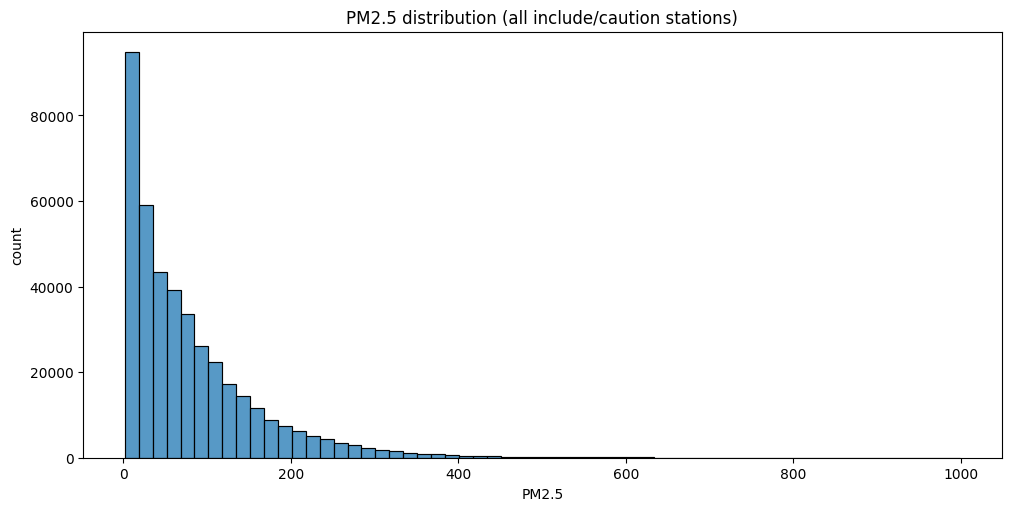

In [164]:
pm25_plot = df_eda[PM25_COL].astype(float).dropna()

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

if _HAVE_SEABORN:
    import seaborn as sns

    sns.histplot(pm25_plot, bins=60, kde=False, ax=ax, color='tab:blue')
else:
    ax.hist(pm25_plot.to_numpy(), bins=60, color='tab:blue', alpha=0.85)

ax.set_title('PM2.5 distribution (all include/caution stations)')
ax.set_xlabel('PM2.5')
ax.set_ylabel('count')

plt.show()
fig.savefig(FIG_DIR / FIG_PM25_GLOBAL, dpi=150)
plt.close(fig)


### Curated figure — PM2.5 by station (ordered boxplot)

Purpose: compare station-level dispersion and medians (ordering by station median).


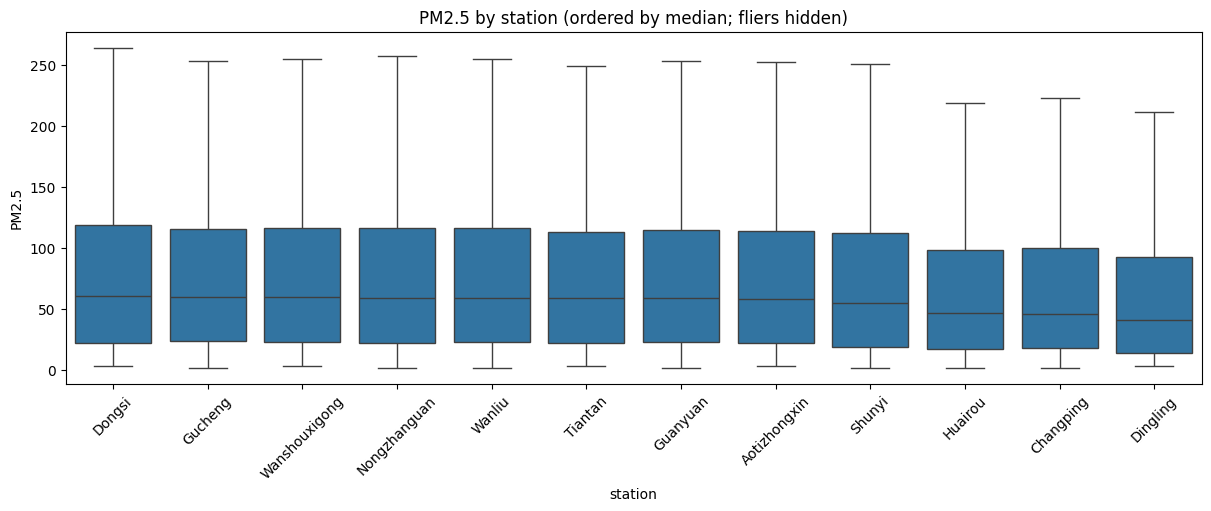

In [165]:
order = (
    pm25_summary_by_station[['station', 'p50']]
    .sort_values('p50', ascending=False)['station']
    .astype(str)
    .tolist()
)

plot_df = df_eda[['station', PM25_COL]].copy()
plot_df['station'] = plot_df['station'].astype(str)
plot_df[PM25_COL] = plot_df[PM25_COL].astype(float)

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

if _HAVE_SEABORN:
    import seaborn as sns

    sns.boxplot(
        data=plot_df,
        x='station',
        y=PM25_COL,
        order=order,
        showfliers=False,
        ax=ax,
        color='tab:blue',
    )
else:
    data = [plot_df.loc[plot_df['station'] == s, PM25_COL].dropna().to_numpy() for s in order]
    ax.boxplot(data, labels=order, showfliers=False)

ax.set_title('PM2.5 by station (ordered by median; fliers hidden)')
ax.set_xlabel('station')
ax.set_ylabel('PM2.5')
ax.tick_params(axis='x', rotation=45)

plt.show()
fig.savefig(FIG_DIR / FIG_PM25_BY_STATION, dpi=150)
plt.close(fig)


## 6. Station heterogeneity and cross-station comparison

Question: *Do stations differ systematically by month/season, beyond overall level differences?*

Notebook 03 relevance: informs whether the contract should expect station×season interaction and report performance by season (no feature decisions made here).


In [166]:
df_eda['year_month'] = df_eda['timestamp'].dt.to_period('M').astype(str)


### Curated figure — Station × month median PM2.5 heatmap

Purpose: see cross-station seasonality and whether some stations run systematically higher/lower (descriptive).


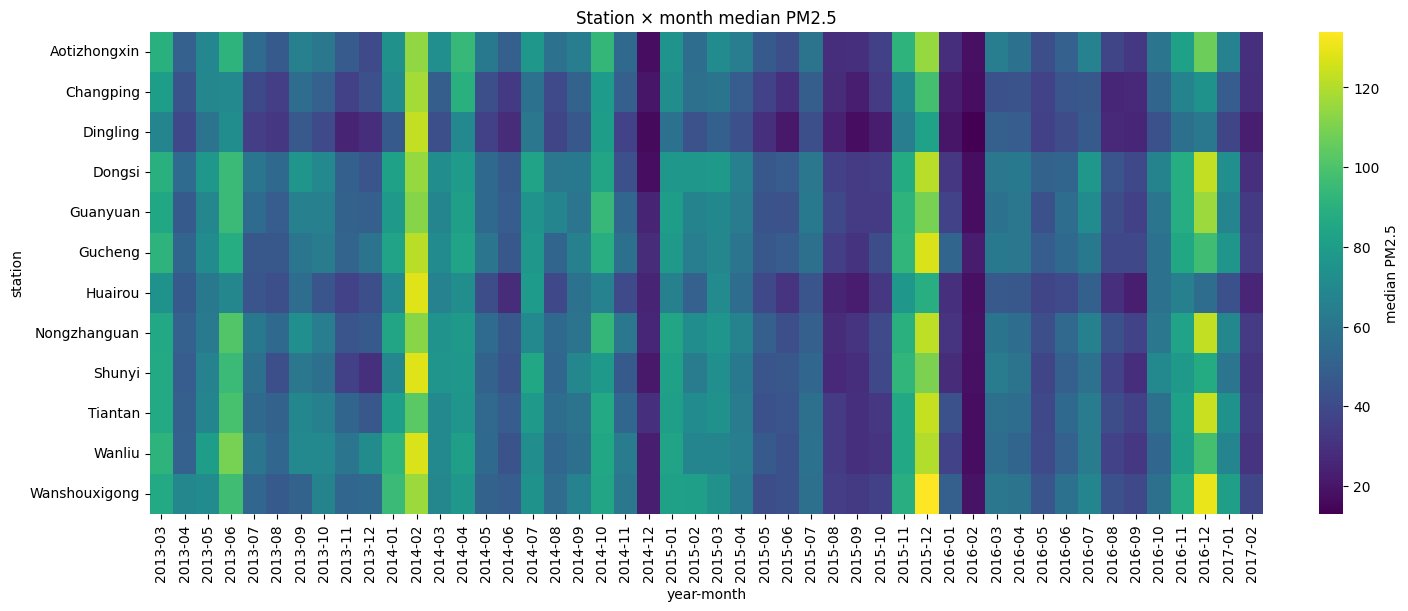

In [167]:
station_month_pm25 = (
    df_eda
    .assign(PM25=lambda d: d[PM25_COL].astype(float))
    .groupby(['station', 'year_month'], as_index=False)
    .agg(
        pm25_count=('PM25', lambda s: int(s.notna().sum())),
        pm25_median=('PM25', 'median'),
        pm25_mean=('PM25', 'mean'),
        pm25_p95=('PM25', lambda s: float(s.quantile(0.95))),
    )
)
station_month_pm25.to_parquet(TAB_DIR / TAB_STATION_MONTH_PM25, index=False)

heat = station_month_pm25.pivot(index='station', columns='year_month', values='pm25_median')

fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

if _HAVE_SEABORN:
    import seaborn as sns

    sns.heatmap(heat, ax=ax, cmap='viridis', cbar_kws={'label': 'median PM2.5'})
else:
    im = ax.imshow(heat.to_numpy(), aspect='auto')
    ax.figure.colorbar(im, ax=ax, label='median PM2.5')
    ax.set_yticks(np.arange(heat.shape[0]))
    ax.set_yticklabels(heat.index.tolist())
    ax.set_xticks(np.arange(heat.shape[1]))
    ax.set_xticklabels(heat.columns.tolist(), rotation=90)

ax.set_title('Station × month median PM2.5')
ax.set_xlabel('year-month')
ax.set_ylabel('station')

plt.show()
fig.savefig(FIG_DIR / FIG_STATION_MONTH_HEATMAP, dpi=150)
plt.close(fig)


## 7. Temporal patterns in PM2.5

Question: *Is there clear within-day and month-to-month structure in PM2.5 central tendency?*

Notebook 03 relevance: informs which time-of-day / seasonal slices to include in diagnostics and evaluation summaries (not feature engineering).


In [168]:
df_eda['hour_of_day'] = df_eda['timestamp'].dt.hour


### Curated figure — Diurnal PM2.5 profile (global median)

Purpose: summarize within-day structure using include/caution stations only (descriptive).


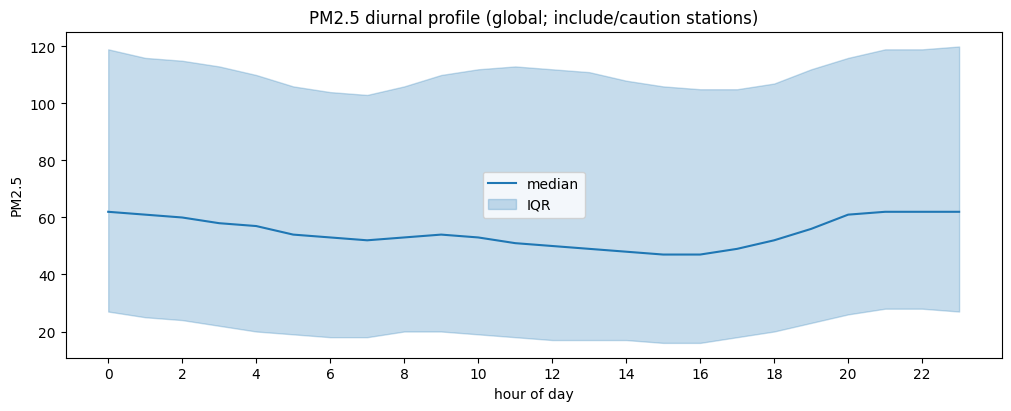

In [169]:
df_eda['date'] = df_eda['timestamp'].dt.date
df_eda['year_month'] = df_eda['timestamp'].dt.to_period('M').astype(str)

pm25_temporal_hour = (
    df_eda
    .assign(PM25=lambda d: d[PM25_COL].astype(float))
    .groupby(['hour_of_day'], as_index=False)
    .agg(
        pm25_count=('PM25', lambda s: int(s.notna().sum())),
        pm25_median=('PM25', 'median'),
        pm25_p25=('PM25', lambda s: float(s.quantile(0.25))),
        pm25_p75=('PM25', lambda s: float(s.quantile(0.75))),
        pm25_mean=('PM25', 'mean'),
    )
)

pm25_temporal_month = (
    df_eda
    .assign(PM25=lambda d: d[PM25_COL].astype(float))
    .groupby(['year_month'], as_index=False)
    .agg(
        pm25_count=('PM25', lambda s: int(s.notna().sum())),
        pm25_median=('PM25', 'median'),
        pm25_mean=('PM25', 'mean'),
        pm25_p95=('PM25', lambda s: float(s.quantile(0.95))),
    )
    .sort_values('year_month')
    .reset_index(drop=True)
)

pm25_temporal_aggs = pd.concat(
    [
        pm25_temporal_hour.assign(grain='hour_of_day'),
        pm25_temporal_month.assign(grain='year_month'),
    ],
    ignore_index=True,
    sort=False,
)
pm25_temporal_aggs.to_parquet(TAB_DIR / TAB_PM25_TEMPORAL_AGGS, index=False)

# Diurnal figure
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

ax.plot(pm25_temporal_hour['hour_of_day'], pm25_temporal_hour['pm25_median'], color='tab:blue', label='median')
ax.fill_between(
    pm25_temporal_hour['hour_of_day'],
    pm25_temporal_hour['pm25_p25'],
    pm25_temporal_hour['pm25_p75'],
    color='tab:blue',
    alpha=0.25,
    label='IQR',
)
ax.set_title('PM2.5 diurnal profile (global; include/caution stations)')
ax.set_xlabel('hour of day')
ax.set_ylabel('PM2.5')
ax.set_xticks(list(range(0, 24, 2)))
ax.legend(loc='best')

plt.show()
fig.savefig(FIG_DIR / FIG_PM25_DIURNAL, dpi=150)
plt.close(fig)


### Curated figure — Monthly PM2.5 trend (global median)

Purpose: visualize longer-term seasonality and trend in central tendency (descriptive).


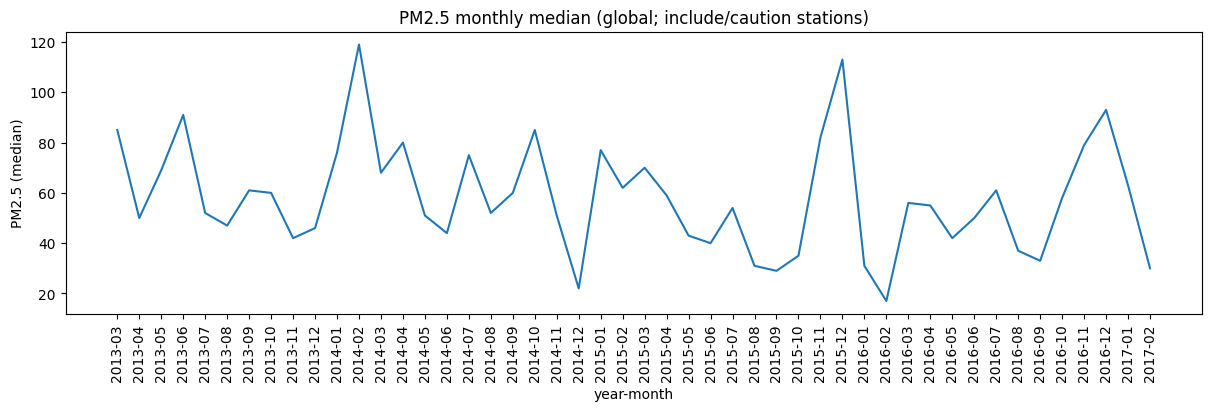

In [170]:
# Use pm25_temporal_month from the previous cell

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
ax.plot(pm25_temporal_month['year_month'], pm25_temporal_month['pm25_median'], color='tab:blue')

ax.set_title('PM2.5 monthly median (global; include/caution stations)')
ax.set_xlabel('year-month')
ax.set_ylabel('PM2.5 (median)')
ax.tick_params(axis='x', rotation=90)

plt.show()
fig.savefig(FIG_DIR / FIG_PM25_MONTHLY_TREND, dpi=150)
plt.close(fig)


## 8. Pollutant co-movement

Question: *How strongly do pollutants and numeric weather variables move together in this dataset (descriptively)?*

Notebook 03 relevance: informs which candidate exogenous signals might be worth testing later and where collinearity could complicate interpretation.


In [171]:
corr_vars = [c for c in (POLLUTANTS + METEOROLOGY) if c in df_eda.columns]


### Curated figure — Correlation heatmap (pollutants + numeric meteorology)

Purpose: summarize pairwise linear associations among pollutants and numeric weather variables (descriptive).

Note: persisted correlation tables are saved as **unique-pair long-form** (unordered variable pairs only; diagonal and symmetric duplicates removed).


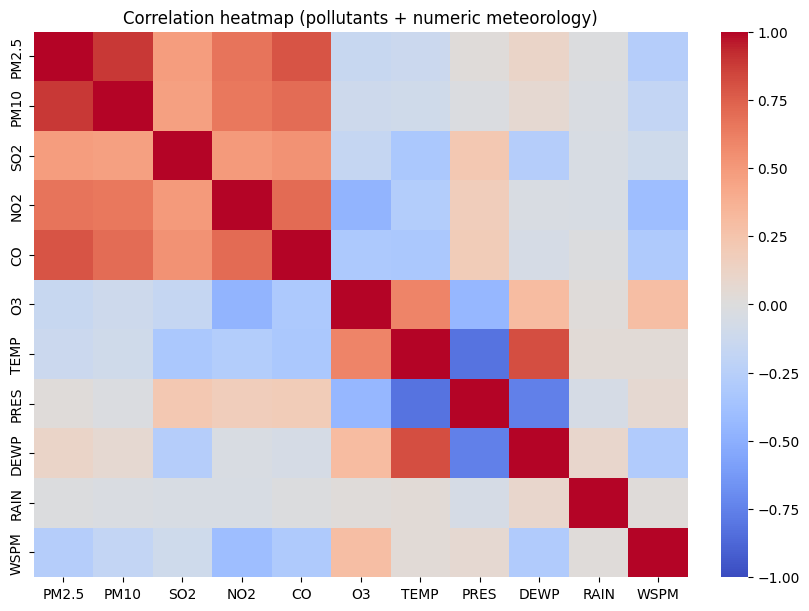

In [172]:
corr_df = df_eda[corr_vars].copy()

# Keep only numeric columns for correlation
numeric_cols = [c for c in corr_df.columns if pd.api.types.is_numeric_dtype(corr_df[c])]
if not numeric_cols:
    raise ValueError('No numeric columns available for correlation analysis')

corr_mat = corr_df[numeric_cols].astype(float).corr()

# Persist unique-pair long-form (exclude diagonal + symmetric duplicates)
corr_mask = np.triu(np.ones(corr_mat.shape, dtype=bool), k=1)
corr_long = corr_mat.where(corr_mask).stack().reset_index()
corr_long.columns = ['var_x', 'var_y', 'corr']
# Defensive uniqueness (unordered pairs only; no diagonal)
corr_long = corr_long.loc[corr_long['var_x'] != corr_long['var_y']].copy()
corr_long['pair_key'] = corr_long.apply(
    lambda r: '||'.join(sorted([str(r['var_x']), str(r['var_y'])])), axis=1
)
corr_long = corr_long.drop_duplicates('pair_key').drop(columns=['pair_key']).reset_index(drop=True)
corr_long.to_parquet(TAB_DIR / TAB_CORR_GLOBAL, index=False)

# Correlations by season (simple month-based season labels)
df_season = df_eda[['timestamp'] + numeric_cols].copy()
df_season['month'] = df_season['timestamp'].dt.month

def _season_from_month(m: int) -> str:
    if m in (12, 1, 2):
        return 'DJF'
    if m in (3, 4, 5):
        return 'MAM'
    if m in (6, 7, 8):
        return 'JJA'
    if m in (9, 10, 11):
        return 'SON'
    return 'UNK'

season_rows = []
for season, g in df_season.groupby(df_season['month'].map(_season_from_month)):
    cm = g[numeric_cols].astype(float).corr()
    mask = np.triu(np.ones(cm.shape, dtype=bool), k=1)
    cl = cm.where(mask).stack().reset_index()
    cl.columns = ['var_x', 'var_y', 'corr']
    # Defensive uniqueness (unordered pairs only; no diagonal)
    cl = cl.loc[cl['var_x'] != cl['var_y']].copy()
    cl['pair_key'] = cl.apply(
        lambda r: '||'.join(sorted([str(r['var_x']), str(r['var_y'])])), axis=1
    )
    cl = cl.drop_duplicates('pair_key').drop(columns=['pair_key']).reset_index(drop=True)
    cl.insert(0, 'season', season)
    season_rows.append(cl)

corr_by_season = pd.concat(season_rows, ignore_index=True)
corr_by_season.to_parquet(TAB_DIR / TAB_CORR_BY_SEASON, index=False)

# Plot heatmap (global)
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

if _HAVE_SEABORN:
    import seaborn as sns

    sns.heatmap(corr_mat, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, center=0, annot=False)
else:
    im = ax.imshow(corr_mat.to_numpy(), vmin=-1, vmax=1, cmap='coolwarm')
    ax.figure.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(numeric_cols)))
    ax.set_yticklabels(numeric_cols)

ax.set_title('Correlation heatmap (pollutants + numeric meteorology)')

plt.show()
fig.savefig(FIG_DIR / FIG_CORR_HEATMAP, dpi=150)
plt.close(fig)


## 9. Weather relationships

Question: *How does PM2.5 vary across coarse weather bins and along wind-related dimensions?*

Notebook 03 relevance: informs whether weather variables plausibly carry usable predictive signal and which diagnostics to prioritize (still descriptive; no causal claims).

No causal claims are made in this section; plots/tables are descriptive associations.


### Weather-binned summaries (support table)

Purpose: coarse descriptive summaries of PM2.5 conditioned on a few weather bins (for later hypothesis generation).


In [173]:
rows = []

# Wind speed bins (quantiles)
if 'WSPM' in df_eda.columns:
    wspm = df_eda['WSPM'].astype(float)
    wspm_bins = pd.qcut(wspm, q=5, duplicates='drop')
    tmp = df_eda.assign(_bin=wspm_bins, PM25=df_eda[PM25_COL].astype(float))
    for b, g in tmp.groupby('_bin'):
        s = g['PM25']
        rows.append({
            'condition_var': 'WSPM',
            'bin': str(b),
            'n': int(s.notna().sum()),
            'pm25_median': float(s.median()),
            'pm25_mean': float(s.mean()),
            'pm25_p95': float(s.quantile(0.95)),
        })

# Temperature bins (quantiles)
if 'TEMP' in df_eda.columns:
    temp = df_eda['TEMP'].astype(float)
    temp_bins = pd.qcut(temp, q=5, duplicates='drop')
    tmp = df_eda.assign(_bin=temp_bins, PM25=df_eda[PM25_COL].astype(float))
    for b, g in tmp.groupby('_bin'):
        s = g['PM25']
        rows.append({
            'condition_var': 'TEMP',
            'bin': str(b),
            'n': int(s.notna().sum()),
            'pm25_median': float(s.median()),
            'pm25_mean': float(s.mean()),
            'pm25_p95': float(s.quantile(0.95)),
        })

weather_binned = pd.DataFrame(rows)
weather_binned.to_parquet(TAB_DIR / TAB_WEATHER_BINNED, index=False)
weather_binned


,condition_var,bin,n,pm25_median,pm25_mean,pm25_p95
0,WSPM,"(-0.001, 0.8]",90634,77.0,102.438308,282.0
1,WSPM,"(0.8, 1.2]",85780,73.0,97.792807,273.0
2,WSPM,"(1.2, 1.7]",84230,61.0,84.076854,244.0
3,WSPM,"(1.7, 2.5]",72719,47.0,67.367241,200.0
4,WSPM,"(2.5, 13.2]",78349,19.0,40.809889,142.0
5,TEMP,"(-19.901, 1.5]",83576,61.0,97.327733,322.0
6,TEMP,"(1.5, 9.8]",81924,56.0,86.316700,264.0
7,TEMP,"(9.8, 18.6]",82514,51.0,77.203748,245.0
8,TEMP,"(18.6, 24.7]",82235,54.0,69.615785,184.0
9,TEMP,"(24.7, 41.6]",81382,56.0,68.141104,172.0


### Curated figure — PM2.5 vs wind speed (hexbin)

Purpose: visualize association shape and density between PM2.5 and wind speed.


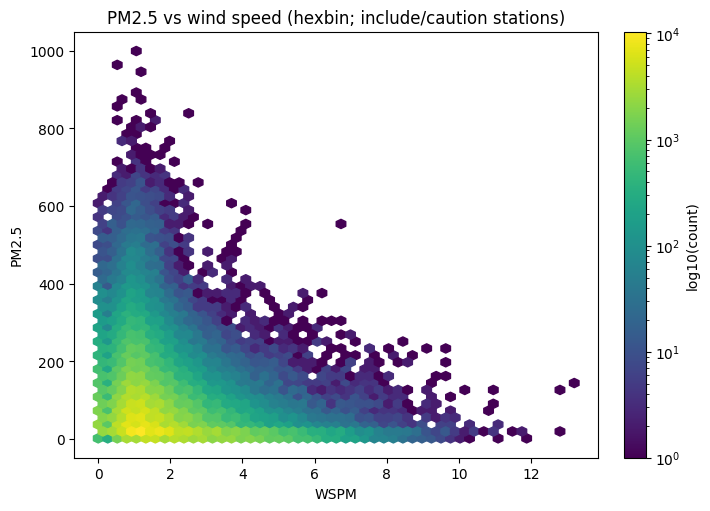

In [174]:
if 'WSPM' not in df_eda.columns:
    raise ValueError('Missing column WSPM for hexbin plot')

hex_df = df_eda[[PM25_COL, 'WSPM']].copy()
hex_df[PM25_COL] = hex_df[PM25_COL].astype(float)
hex_df['WSPM'] = hex_df['WSPM'].astype(float)
hex_df = hex_df.dropna()

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

hb = ax.hexbin(
    hex_df['WSPM'].to_numpy(),
    hex_df[PM25_COL].to_numpy(),
    gridsize=50,
    bins='log',
    cmap='viridis',
)
cb = fig.colorbar(hb, ax=ax)
cb.set_label('log10(count)')

ax.set_title('PM2.5 vs wind speed (hexbin; include/caution stations)')
ax.set_xlabel('WSPM')
ax.set_ylabel('PM2.5')

plt.show()
fig.savefig(FIG_DIR / FIG_PM25_WSPM_HEXBIN, dpi=150)
plt.close(fig)


### Curated figure — PM2.5 by wind direction token

Purpose: compare typical PM2.5 levels across `wd` categories (descriptive; tokens not harmonized here).


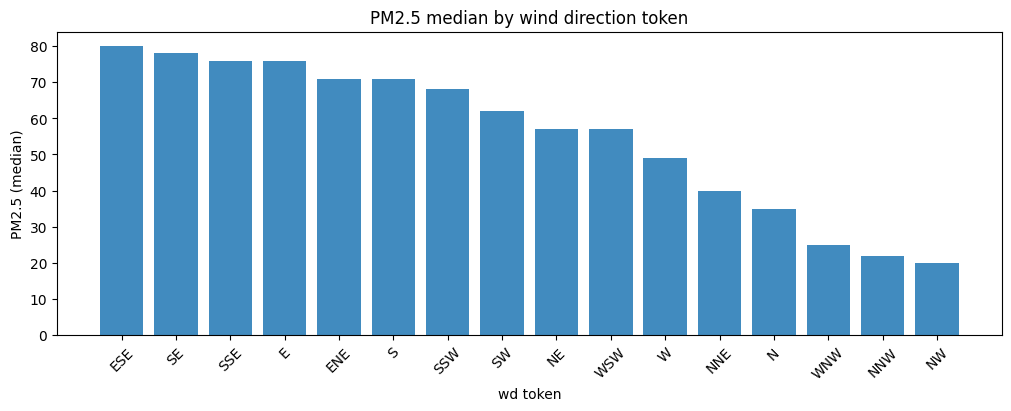

In [175]:
if 'wd' not in df_eda.columns:
    raise ValueError('Missing column wd for wind-direction summary')

wd_df = df_eda[['wd', PM25_COL]].copy()
wd_df['wd'] = wd_df['wd'].astype(str)
wd_df[PM25_COL] = wd_df[PM25_COL].astype(float)

wd_summary = (
    wd_df
    .groupby('wd', as_index=False)
    .agg(
        pm25_count=(PM25_COL, lambda s: int(s.notna().sum())),
        pm25_median=(PM25_COL, 'median'),
        pm25_p95=(PM25_COL, lambda s: float(s.quantile(0.95))),
    )
    .sort_values('pm25_median', ascending=False)
    .reset_index(drop=True)
)

# Plot all categories (typically small cardinality)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.bar(wd_summary['wd'], wd_summary['pm25_median'], color='tab:blue', alpha=0.85)
ax.set_title('PM2.5 median by wind direction token')
ax.set_xlabel('wd token')
ax.set_ylabel('PM2.5 (median)')
ax.tick_params(axis='x', rotation=45)

plt.show()
fig.savefig(FIG_DIR / FIG_PM25_WD_BAR, dpi=150)
plt.close(fig)


## 10. High-pollution episodes

Question: *Under a simple operational definition, what do high-pollution episodes look like in duration and seasonality?*

Notebook 03 relevance: informs later evaluation slices (e.g., performance during high-PM2.5 regimes) without turning episodes into a target definition.


### Episode definition (operational, descriptive)

We define an episode as a **station-local run** of consecutive hours where PM2.5 exceeds the **global p95** threshold, lasting at least `MIN_EPISODE_HOURS` hours. This is a descriptive device to summarize high-pollution periods; it is not a modeling target definition.


In [176]:
# Threshold definition inputs
pm25_for_thresh = df_eda[PM25_COL].astype(float).dropna()
if pm25_for_thresh.empty:
    raise ValueError('PM2.5 is entirely missing after include/caution filtering')

episode_threshold = float(pm25_for_thresh.quantile(0.95))

pd.DataFrame(
    {
        'metric': ['PM2.5 global p95 threshold', 'MIN_EPISODE_HOURS'],
        'value': [episode_threshold, int(MIN_EPISODE_HOURS)],
    }
)


,metric,value
0,PM2.5 global p95 threshold,242.0
1,MIN_EPISODE_HOURS,6.0


In [177]:
# Helper: extract station-local run events above threshold
def extract_episode_events(df_station: pd.DataFrame, threshold_value: float, min_hours: int) -> pd.DataFrame:
    g = df_station.sort_values('timestamp').copy()
    s = g[PM25_COL].astype(float)
    above = s > float(threshold_value)

    # Identify run starts/ends using changes in the boolean mask
    change = above.ne(above.shift(fill_value=False))
    run_id = change.cumsum()

    events = []
    for _, rg in g.loc[above].groupby(run_id[above]):
        start_ts = rg['timestamp'].iloc[0]
        end_ts = rg['timestamp'].iloc[-1]
        dur_hours = int((end_ts - start_ts) / pd.Timedelta(hours=1)) + 1
        if dur_hours >= int(min_hours):
            events.append({
                'station': str(rg['station'].iloc[0]),
                'start_ts': start_ts,
                'end_ts': end_ts,
                'duration_hours': dur_hours,
                'threshold_pm25': float(threshold_value),
            })

    return pd.DataFrame(events)


In [178]:
# Extract per-station episode events
episode_events_list = []
for st, g in df_eda.groupby('station', sort=True):
    ev = extract_episode_events(g[['station', 'timestamp', PM25_COL]], episode_threshold, MIN_EPISODE_HOURS)
    if not ev.empty:
        episode_events_list.append(ev)

episode_events = (
    pd.concat(episode_events_list, ignore_index=True)
    if episode_events_list
    else pd.DataFrame(columns=['station', 'start_ts', 'end_ts', 'duration_hours', 'threshold_pm25'])
)

episode_events.head(10)


,station,start_ts,end_ts,duration_hours,threshold_pm25
0,Aotizhongxin,2013-03-07 03:00:00,2013-03-07 09:00:00,7,242.0
1,Aotizhongxin,2013-03-07 21:00:00,2013-03-08 10:00:00,14,242.0
2,Aotizhongxin,2013-03-15 15:00:00,2013-03-16 11:00:00,21,242.0
3,Aotizhongxin,2013-03-17 09:00:00,2013-03-18 02:00:00,18,242.0
4,Aotizhongxin,2013-05-05 20:00:00,2013-05-06 13:00:00,18,242.0
5,Aotizhongxin,2013-06-28 02:00:00,2013-06-28 22:00:00,21,242.0
6,Aotizhongxin,2013-06-30 19:00:00,2013-07-01 01:00:00,7,242.0
7,Aotizhongxin,2013-09-28 09:00:00,2013-09-28 14:00:00,6,242.0
8,Aotizhongxin,2013-09-28 19:00:00,2013-09-29 07:00:00,13,242.0
9,Aotizhongxin,2013-10-04 21:00:00,2013-10-05 05:00:00,9,242.0


In [179]:
# Episode summaries + persistence
episode_events.to_parquet(TAB_DIR / TAB_EPISODE_EVENTS, index=False)

episode_summary = (
    episode_events
    .groupby('station', as_index=False)
    .agg(
        n_episodes=('duration_hours', 'size'),
        total_hours=('duration_hours', 'sum'),
        median_duration=('duration_hours', 'median'),
        p95_duration=('duration_hours', lambda s: float(pd.Series(s).quantile(0.95)) if len(s) else np.nan),
    )
    if not episode_events.empty
    else pd.DataFrame(columns=['station', 'n_episodes', 'total_hours', 'median_duration', 'p95_duration'])
)

episode_summary.to_parquet(TAB_DIR / TAB_EPISODE_SUMMARY, index=False)

episode_summary


,station,n_episodes,total_hours,median_duration,p95_duration
0,Aotizhongxin,95,1512,13.0,40.00
1,Changping,63,932,11.0,40.90
2,Dingling,56,1018,13.0,38.50
3,Dongsi,113,1723,11.0,37.80
4,Guanyuan,99,1444,11.0,39.20
5,Gucheng,101,1540,12.0,38.00
6,Huairou,66,901,10.5,35.25
7,Nongzhanguan,116,1711,10.0,39.25
8,Shunyi,102,1347,10.0,24.95
9,Tiantan,98,1442,10.5,39.05


### Curated figure — Episode duration histogram

Purpose: summarize episode-length distribution under the operational definition above.


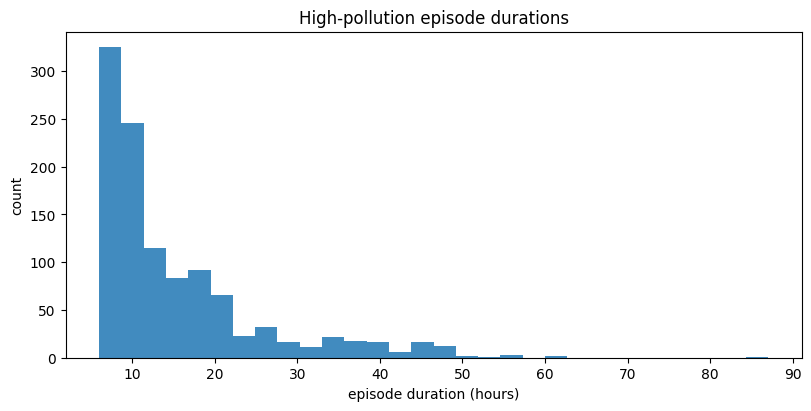

In [180]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

if episode_events.empty:
    ax.text(0.5, 0.5, 'No episodes found under current definition', ha='center', va='center')
    ax.set_axis_off()
else:
    ax.hist(episode_events['duration_hours'].to_numpy(), bins=30, color='tab:blue', alpha=0.85)
    ax.set_xlabel('episode duration (hours)')
    ax.set_ylabel('count')
    ax.set_title('High-pollution episode durations')

plt.show()
fig.savefig(FIG_DIR / FIG_EPISODE_DUR_HIST, dpi=150)
plt.close(fig)


### Curated figure — Station × month episode counts

Purpose: see seasonality and station heterogeneity in high-pollution episode frequency (under the operational definition above).


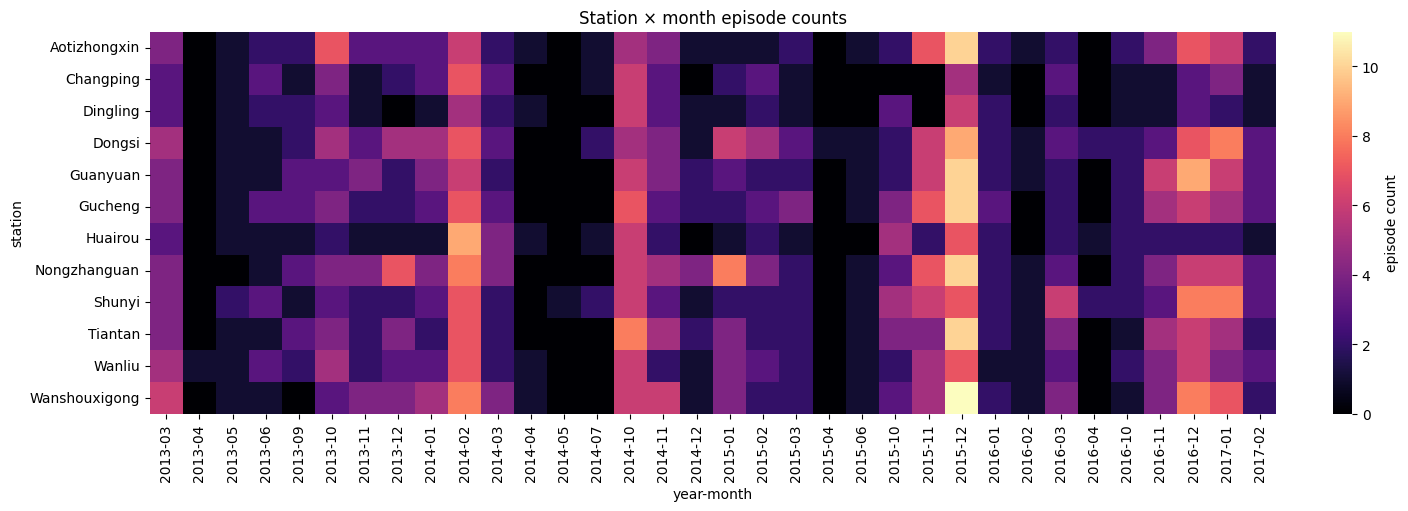

In [181]:
if episode_events.empty:
    station_month_episode = pd.DataFrame(columns=['station', 'year_month', 'episode_count'])
else:
    station_month_episode = episode_events.copy()
    station_month_episode['year_month'] = station_month_episode['start_ts'].dt.to_period('M').astype(str)
    station_month_episode = (
        station_month_episode
        .groupby(['station', 'year_month'], as_index=False)
        .agg(episode_count=('duration_hours', 'size'))
    )

heat = station_month_episode.pivot(index='station', columns='year_month', values='episode_count').fillna(0)

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

if _HAVE_SEABORN and not heat.empty:
    import seaborn as sns
    sns.heatmap(heat, ax=ax, cmap='magma', cbar_kws={'label': 'episode count'})
elif heat.empty:
    ax.text(0.5, 0.5, 'No episode heatmap to show (no episodes found)', ha='center', va='center')
    ax.set_axis_off()
else:
    im = ax.imshow(heat.to_numpy(), aspect='auto', cmap='magma')
    ax.figure.colorbar(im, ax=ax, label='episode count')
    ax.set_yticks(np.arange(heat.shape[0]))
    ax.set_yticklabels(heat.index.tolist())
    ax.set_xticks(np.arange(heat.shape[1]))
    ax.set_xticklabels(heat.columns.tolist(), rotation=90)

ax.set_title('Station × month episode counts')
ax.set_xlabel('year-month')
ax.set_ylabel('station')

plt.show()
fig.savefig(FIG_DIR / FIG_EPISODE_STATION_MONTH, dpi=150)
plt.close(fig)


## 11. EDA evidence register and modeling implications

All implications must reference a specific table or figure produced in this notebook. Implications are provisional and do not implement or freeze modeling choices.


In [182]:
implications_rows = [
    {
        'implication_id': 'EDA-01',
        'observation': 'PM2.5 distribution appears heavy-tailed with high-end outliers at the global level (shape varies by station).',
        'evidence': f"figure:{FIG_PM25_GLOBAL}; figure:{FIG_PM25_BY_STATION}",
        'modeling_implication': 'Hypothesis to test later: evaluation may benefit from robust metrics and/or a target transform; confirm under time-based splits.',
        'risk_or_caveat': 'Distributional choices must be validated under time splits; avoid leakage via global transforms.'
    },
    {
        'implication_id': 'EDA-02',
        'observation': 'Stations differ in typical PM2.5 levels and dispersion.',
        'evidence': f"table:{TAB_PM25_SUMMARY_BY_STATION}; figure:{FIG_PM25_BY_STATION}",
        'modeling_implication': 'Hypothesis to test later: station effects may matter; compare pooled vs station-aware approaches and report station-stratified metrics.',
        'risk_or_caveat': 'Pooling can wash out local dynamics; per-station models may reduce data per series.'
    },
    {
        'implication_id': 'EDA-03',
        'observation': 'Monthly seasonality and station×season interaction are visible in station×month medians.',
        'evidence': f"table:{TAB_STATION_MONTH_PM25}; figure:{FIG_STATION_MONTH_HEATMAP}; figure:{FIG_PM25_MONTHLY_TREND}",
        'modeling_implication': 'Hypothesis to test later: performance may vary by season; include season-stratified diagnostics and validate season-aware evaluation windows.',
        'risk_or_caveat': 'Season definitions should be validated; avoid using future seasonal aggregates in features.'
    },
    {
        'implication_id': 'EDA-04',
        'observation': 'Diurnal structure suggests within-day patterns in central tendency.',
        'evidence': f"table:{TAB_PM25_TEMPORAL_AGGS}; figure:{FIG_PM25_DIURNAL}",
        'modeling_implication': 'Hypothesis to test later: diurnal structure may be useful signal; evaluate time-of-day diagnostics and only add encodings if split-safe gains appear.',
        'risk_or_caveat': 'Diurnal patterns may differ by station/season; pooled summaries can hide heterogeneity.'
    },
    {
        'implication_id': 'EDA-05',
        'observation': 'Pollutants and numeric meteorology show non-trivial correlation structure.',
        'evidence': f"table:{TAB_CORR_GLOBAL}; table:{TAB_CORR_BY_SEASON}; figure:{FIG_CORR_HEATMAP}",
        'modeling_implication': 'Hypothesis to test later: multivariate/exogenous signals may add value; test incremental benefit while monitoring collinearity.',
        'risk_or_caveat': 'Correlations are descriptive and can vary seasonally; do not infer causality.'
    },
    {
        'implication_id': 'EDA-06',
        'observation': 'High-pollution episodes can be summarized by duration and seasonality under an operational threshold.',
        'evidence': f"table:{TAB_EPISODE_EVENTS}; table:{TAB_EPISODE_SUMMARY}; figure:{FIG_EPISODE_DUR_HIST}; figure:{FIG_EPISODE_STATION_MONTH}",
        'modeling_implication': 'Hypothesis to test later: performance may differ in high-PM2.5 regimes; add episode-aware diagnostics as a slice, not a target.',
        'risk_or_caveat': 'Episode definition is arbitrary; sensitivity checks needed before any downstream use.'
    },
]

# Text cleanup (handles any mojibake introduced by prior runs)
for row in implications_rows:
    row['observation'] = (
        str(row['observation'])
        .replace('station�season', 'station×season')
        .replace('station�month', 'station×month')
    )

implications = pd.DataFrame(implications_rows)
implications.to_parquet(TAB_DIR / TAB_IMPLICATIONS, index=False)
implications


,implication_id,observation,evidence,modeling_implication,risk_or_caveat
0,EDA-01,PM2.5 distribution appears heavy-tailed with h...,figure:pm25_distribution_global.png; figure:pm...,Hypothesis to test later: evaluation may benef...,Distributional choices must be validated under...
1,EDA-02,Stations differ in typical PM2.5 levels and di...,table:pm25_summary_by_station.parquet; figure:...,Hypothesis to test later: station effects may ...,Pooling can wash out local dynamics; per-stati...
2,EDA-03,Monthly seasonality and station×season interac...,table:station_month_pm25_summary.parquet; figu...,Hypothesis to test later: performance may vary...,Season definitions should be validated; avoid ...
3,EDA-04,Diurnal structure suggests within-day patterns...,table:pm25_temporal_aggregates.parquet; figure...,Hypothesis to test later: diurnal structure ma...,Diurnal patterns may differ by station/season;...
4,EDA-05,Pollutants and numeric meteorology show non-tr...,table:correlations_global.parquet; table:corre...,Hypothesis to test later: multivariate/exogeno...,Correlations are descriptive and can vary seas...
5,EDA-06,High-pollution episodes can be summarized by d...,table:episode_events.parquet; table:episode_su...,Hypothesis to test later: performance may diff...,Episode definition is arbitrary; sensitivity c...


## 12. Persist selected EDA artifacts

This notebook saves curated figures (stable filenames) under `reports/figures/eda_environmental_signals/` and support tables under `data/interim/beijing_air_quality/eda_environmental_signals/`.

Persisted figures are curated analytical outputs (not every exploratory plot).


In [183]:
expected_figs = [
    FIG_PM25_GLOBAL,
    FIG_PM25_BY_STATION,
    FIG_STATION_MONTH_HEATMAP,
    FIG_PM25_DIURNAL,
    FIG_PM25_MONTHLY_TREND,
    FIG_CORR_HEATMAP,
    FIG_PM25_WSPM_HEXBIN,
    FIG_PM25_WD_BAR,
    FIG_EPISODE_DUR_HIST,
    FIG_EPISODE_STATION_MONTH,
]

expected_tabs = [
    TAB_PM25_SUMMARY_GLOBAL,
    TAB_PM25_SUMMARY_BY_STATION,
    TAB_STATION_MONTH_PM25,
    TAB_PM25_TEMPORAL_AGGS,
    TAB_CORR_GLOBAL,
    TAB_CORR_BY_SEASON,
    TAB_WEATHER_BINNED,
    TAB_EPISODE_SUMMARY,
    TAB_EPISODE_EVENTS,
    TAB_IMPLICATIONS,
]

status_rows = []
for fn in expected_figs:
    p = FIG_DIR / fn
    status_rows.append({'artifact_type': 'figure', 'filename': fn, 'exists': bool(p.exists()), 'path': str(p)})
for fn in expected_tabs:
    p = TAB_DIR / fn
    status_rows.append({'artifact_type': 'table', 'filename': fn, 'exists': bool(p.exists()), 'path': str(p)})

artifact_status = pd.DataFrame(status_rows)
artifact_status


,artifact_type,filename,exists,path
0,figure,pm25_distribution_global.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
1,figure,pm25_by_station_boxplot.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
2,figure,station_month_pm25_heatmap.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
3,figure,pm25_diurnal_profile.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
4,figure,pm25_monthly_trend.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
5,figure,corr_heatmap_pollutants_meteo.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
6,figure,pm25_vs_wspm_hexbin.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
7,figure,pm25_by_wd_bar.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
8,figure,episode_duration_hist.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...
9,figure,episode_station_month_heatmap.png,True,F:\DOCUMENTOS\CIENCIA DE DATOS\PROYECTOS\portf...


## 13. Notebook close

Notebook 02 ends after descriptive EDA outputs (curated figures, support tables, and an evidence-backed implications register).

Notebook 03 will use these outputs to design the forecasting problem contract.
